# Figure05X — When Do Collapsing Bounds Help?

## Summary

For all three mixed-block (MX) reward structures used in the pigeon task, the optimal
decision boundary for an SNR-agnostic observer is **flat or increasing**, not collapsing.
This holds for the actual pigeon-task SNR pair {μ=0.05, μ=0.15}.

Adding zero-SNR (μ=0) trials to the mix can shift the global optimum toward collapsing, but
the **reward-rate advantage over flat is negligible** — well under 1% in all cases.

### Why collapsing does NOT help for two non-zero SNRs

For each reward structure, the optimal flat bound is monotonically decreasing in μ: harder
(lower-μ) trials require a higher position threshold to accumulate sufficient evidence.
An agnostic observer facing a mixture therefore benefits from an **increasing** bound —
start lower to capture early easy-trial exits, then rise to handle the harder trials that
persist.  A collapsing bound does the opposite and is suboptimal.

### Why adding zero-SNR gives only a slight advantage

Zero-SNR (μ=0) trials are informationally useless: the walk is symmetric, so the evidence
never converges.  When such trials persist to late timesteps, a collapsing bound reduces
further wasteful accumulation.  But in the pigeon task the effect is tiny because the
proportion of zero-SNR survivors at late steps is small and the non-zero-SNR landscape
strongly favours increasing bounds.

---

**Bound parameterisation:**  $B(t) = B_{ini} + (B_{fin}-B_{ini})\cdot\min(t,\,T_{change})/T_{change}$

The (B_ini, B_fin) grid covers all cases on a single heatmap:
- **Diagonal** (B_fin = B_ini): flat bound
- **Upper-left** (B_fin > B_ini): increasing bound
- **Lower-right** (B_fin < B_ini): collapsing bound


In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ── Task parameters ───────────────────────────────────────────────────────────
G_STD     = 0.15    # noise SD per step (shared across all SNR levels)
MAX_STEPS = 300     # trial cutoff; long enough that zero-SNR trials can accumulate
T_CHANGE  = 30      # steps over which the bound ramps from B_ini to B_fin
N_TRIALS  = 60_000  # trajectories per SNR level
ITI       = 0       # inter-trial interval (steps)

# ── Block reward structures ───────────────────────────────────────────────────
# Matches pigeon.simulate BLOCK_DEFS entries 1-3:
#   1: coins_gained=1, coins_lost=0, steps_lost=0   (gain only)
#   2: coins_gained=1, coins_lost=4, steps_lost=0   (coin penalty)
#   3: coins_gained=1, coins_lost=0, steps_lost=30  (time-out penalty)
BD1 = dict(coins_gained=1, coins_lost=0, steps_lost=0)
BD2 = dict(coins_gained=1, coins_lost=4, steps_lost=0)
BD3 = dict(coins_gained=1, coins_lost=0, steps_lost=30)

BLOCK_DEFS = {1: BD1, 2: BD2, 3: BD3}

# ── Bound grid ────────────────────────────────────────────────────────────────
# 20 evenly-spaced values; (B_ini, B_fin) ∈ RR_BOUNDS² → 20×20 = 400 grid cells.
RR_BOUNDS = np.arange(0.01, 0.81, 0.04)
n = len(RR_BOUNDS)

# Matrix indexing: rr_matrix[fin_idx, ini_idx]
# With imshow(origin='lower'): x-axis = ini_idx, y-axis = fin_idx.
# Upper-left  (fin_idx > ini_idx, B_fin > B_ini): increasing — above the diagonal
# Lower-right (fin_idx < ini_idx, B_fin < B_ini): collapsing — below the diagonal
COLL_MASK = np.triu(np.ones((n, n), bool), k=1)   # ini_idx > fin_idx → collapsing
INCR_MASK = np.tril(np.ones((n, n), bool), k=-1)  # fin_idx > ini_idx → increasing

rng = np.random.default_rng(42)


In [7]:
print("Generating trajectories (one set reused across all blocks and conditions)...")
trajs = {}   # trajs[mu] → (N_TRIALS, MAX_STEPS+1) float32 cumulative DV array
ndts  = {}   # ndts[mu]  → (N_TRIALS,) int array of non-decision times

for mu in [0.0, 0.05, 0.15]:
    noise = rng.normal(mu, G_STD, (N_TRIALS, MAX_STEPS))
    DV = np.concatenate(
        [np.zeros((N_TRIALS, 1)), np.cumsum(noise, axis=1)], axis=1
    ).astype(np.float32)
    trajs[mu] = DV
    ndts[mu]  = rng.integers(0, 2, N_TRIALS)   # uniform NDT ∈ {0, 1}
    print(f"  μ={mu:.2f}  {N_TRIALS:,} trials  ({DV.nbytes/1e6:.0f} MB)")


Generating trajectories (one set reused across all blocks and conditions)...
  μ=0.00  60,000 trials  (72 MB)
  μ=0.05  60,000 trials  (72 MB)
  μ=0.15  60,000 trials  (72 MB)


In [8]:
def compute_rr_matrix(mu_list, bd, iti=ITI):
    """
    Compute the (B_ini, B_fin) reward-rate matrix for a mixture of SNR levels.

    All SNR levels in mu_list use the same time-varying bound on every trial.
    Handles coins_lost (coin penalty) and steps_lost (time-out penalty) for
    incorrect trials.  Returns rr_matrix[fin_idx, ini_idx].
    """
    t  = np.arange(MAX_STEPS, dtype=np.float32)
    rm = np.zeros((n, n))
    steps_lost = bd.get('steps_lost', 0)

    for ini_idx, B_ini in enumerate(RR_BOUNDS):
        for fin_idx, B_fin in enumerate(RR_BOUNDS):
            frac = np.minimum(t, T_CHANGE) / T_CHANGE
            B_t  = (B_ini + (B_fin - B_ini) * frac).astype(np.float32)

            tc, ts = 0.0, 0.0

            for mu in mu_list:
                DV, ndt = trajs[mu], ndts[mu]
                N = len(ndt)

                # First time |DV| ≥ B_t; use MAX_STEPS if threshold never crossed.
                crossed = np.abs(DV[:, 1:]) >= B_t[None, :]
                any_c   = crossed.any(axis=1)
                si      = np.where(any_c, np.argmax(crossed, axis=1) + 1, MAX_STEPS)

                # Correct if DV is on the positive side at the stopping step.
                correct = DV[np.arange(N), si] > 0

                coins = np.where(correct, bd['coins_gained'], -bd['coins_lost'])
                extra = np.where(correct, 0, steps_lost)   # time-out for incorrect

                tc += coins.sum()
                ts += (si + ndt + iti + 1 + extra).sum()

            rm[fin_idx, ini_idx] = tc / ts
    return rm


def summarise(rm):
    """Return (flat_best, coll_best, incr_best, b_flat, Bi, Bf, kind) for a matrix."""
    flat_vals = [rm[i, i] for i in range(n)]
    flat = max(flat_vals)
    fi   = int(np.argmax(flat_vals))
    coll = rm[COLL_MASK].max()
    incr = rm[INCR_MASK].max()
    bf, bi = np.unravel_index(rm.argmax(), rm.shape)
    Bi, Bf = RR_BOUNDS[bi], RR_BOUNDS[bf]
    kind = ('coll' if Bf < Bi - 1e-9 else
            'incr' if Bf > Bi + 1e-9 else 'flat')
    return flat, coll, incr, RR_BOUNDS[fi], Bi, Bf, kind


In [9]:
# Compute 6 reward-rate matrices: 3 blocks × {without / with zero-SNR}
RMS = {}

for block, bd in BLOCK_DEFS.items():
    for with_zero in [False, True]:
        mu_list = [0.0, 0.05, 0.15] if with_zero else [0.05, 0.15]
        snr_str = '{0, 0.05, 0.15}' if with_zero else '{0.05, 0.15}'
        print(f"Block {block}, μ ∈ {snr_str} …")
        RMS[(block, with_zero)] = compute_rr_matrix(mu_list, bd)

print("\nDone.  Summary (flat / coll / incr best RR, Δ=coll−flat):")
print(f"  {'Block':<8}  {'SNR cond':<18}  {'global opt':<6}  "
      f"{'flat':>10}  {'coll':>10}  {'incr':>10}  {'Δcoll−flat':>12}")
for block in [1, 2, 3]:
    for with_zero in [False, True]:
        rm  = RMS[(block, with_zero)]
        flat, coll, incr, b_flat, Bi, Bf, kind = summarise(rm)
        snr = 'w/ zero-SNR' if with_zero else 'no zero-SNR'
        delta_pct = 100 * (coll - flat) / abs(flat)
        print(f"  Block {block}   {snr:<18}  {kind:<6}  "
              f"{flat:10.5f}  {coll:10.5f}  {incr:10.5f}  {delta_pct:+10.3f}%")


Block 1, μ ∈ {0.05, 0.15} …
Block 1, μ ∈ {0, 0.05, 0.15} …
Block 2, μ ∈ {0.05, 0.15} …
Block 2, μ ∈ {0, 0.05, 0.15} …
Block 3, μ ∈ {0.05, 0.15} …
Block 3, μ ∈ {0, 0.05, 0.15} …

Done.  Summary (flat / coll / incr best RR, Δ=coll−flat):
  Block     SNR cond            global opt        flat        coll        incr    Δcoll−flat
  Block 1   no zero-SNR         flat       0.29285     0.28214     0.29284      -3.655%
  Block 1   w/ zero-SNR         flat       0.26042     0.24613     0.26041      -5.488%
  Block 2   no zero-SNR         incr       0.10539     0.10536     0.10584      -0.033%
  Block 2   w/ zero-SNR         coll       0.00663     0.00691     0.00656      +4.258%
  Block 3   no zero-SNR         incr       0.11406     0.11378     0.11429      -0.246%
  Block 3   w/ zero-SNR         coll       0.06228     0.06243     0.06216      +0.250%


## Formatted supplemental figure

Two rows, three columns:
- **Top row (A–C):** RR heatmap for {μ=0.05, μ=0.15} — the actual pigeon MX task SNRs.
  For all three blocks the global optimum (red star) lies on or above the diagonal,
  confirming that flat or increasing bounds are optimal.
- **Bottom row (D–F):** Same blocks with μ=0 added.
  The optimum may shift into the collapsing region, but the reward-rate gain over flat
  (annotated in each panel) is negligible.

Dashed white line = flat bound diagonal.  White dots = near-optimal region (within 1% of max).


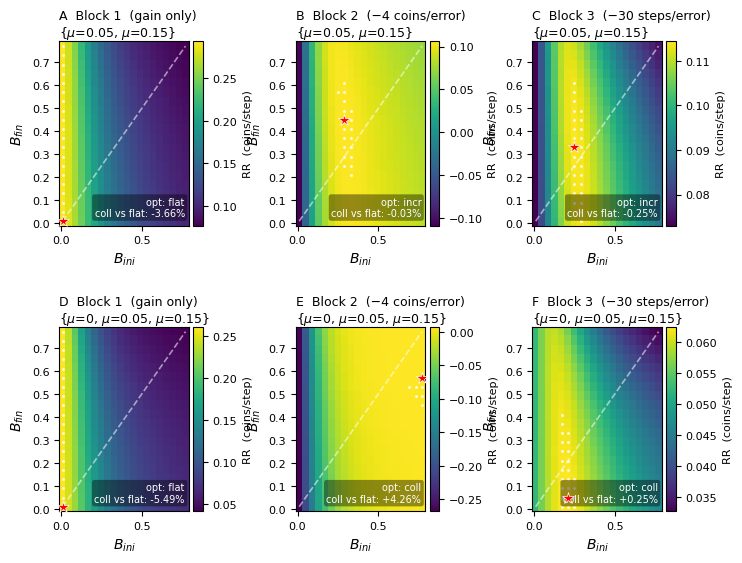

In [10]:
CM  = 1 / 2.54
WID = 18.0   # figure width in cm
FS  = 10

BLOCK_TITLES = {
    1: 'Block 1  (gain only)',
    2: 'Block 2  (−4 coins/error)',
    3: 'Block 3  (−30 steps/error)',
}
ROW_SNR = {
    False: r'{$\mu$=0.05, $\mu$=0.15}',
    True:  r'{$\mu$=0, $\mu$=0.05, $\mu$=0.15}',
}
LETTERS = [['A', 'B', 'C'], ['D', 'E', 'F']]

half   = (RR_BOUNDS[1] - RR_BOUNDS[0]) / 2
extent = [RR_BOUNDS[0] - half, RR_BOUNDS[-1] + half,
          RR_BOUNDS[0] - half, RR_BOUNDS[-1] + half]
diag   = [RR_BOUNDS[0], RR_BOUNDS[-1]]

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

fig, axes = plt.subplots(2, 3, figsize=(WID * CM, WID * 0.78 * CM))
plt.subplots_adjust(left=0.07, right=0.96, bottom=0.08, top=0.93,
                    wspace=0.50, hspace=0.55)

for row, with_zero in enumerate([False, True]):
    for col, block in enumerate([1, 2, 3]):
        ax = axes[row, col]
        rm = RMS[(block, with_zero)]
        flat, coll, incr, b_flat, Bi, Bf, kind = summarise(rm)

        im = ax.imshow(rm, origin='lower', extent=extent, aspect='auto', cmap='viridis')
        cb = plt.colorbar(im, ax=ax, pad=0.03)
        cb.ax.tick_params(labelsize=FS - 2)
        cb.set_label('RR  (coins/step)', fontsize=FS - 2)

        # Near-optimal region (within 1% of global max) — vectorised
        near = np.argwhere(rm >= rm.max() * 0.99)
        if len(near):
            ax.plot(RR_BOUNDS[near[:, 1]], RR_BOUNDS[near[:, 0]], 'w.',
                    ms=2.5, zorder=3, alpha=0.65)

        # Global optimum
        ax.plot(Bi, Bf, 'r*', ms=9, markeredgecolor='white', markeredgewidth=0.5, zorder=5)

        # Flat-bound diagonal
        ax.plot(diag, diag, 'w--', lw=1.2, alpha=0.55, zorder=4)

        ax.set_xlabel('$B_{ini}$', fontsize=FS)
        ax.set_ylabel('$B_{fin}$', fontsize=FS)
        ax.tick_params(labelsize=FS - 2)

        letter = LETTERS[row][col]
        ax.set_title(
            f'{letter}  {BLOCK_TITLES[block]}\n{ROW_SNR[with_zero]}',
            fontsize=FS - 1, loc='left', pad=3,
        )

        # Annotation: optimum type + collapsing advantage over flat
        delta_pct = 100 * (coll - flat) / abs(flat) if flat != 0 else float('nan')
        ax.text(
            0.97, 0.04,
            f'opt: {kind}\ncoll vs flat: {delta_pct:+.2f}%',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=FS - 3, color='white',
            bbox=dict(boxstyle='round,pad=0.25', fc=(0, 0, 0, 0.4), ec='none'),
        )

import os
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/FigureS05X_RRMap.pdf', bbox_inches='tight')
plt.show()
